In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import analysis_utils as auti
import file_utils as futi
import event_utils as euti


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )
importlib.reload( futi )
importlib.reload( euti )

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
# This allow both dict.key and dict['key'] syntax
class AttrDict(dict):
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")

    def __setattr__(self, key, value):
        self[key] = value

    def __delattr__(self, key):
        try:
            del self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")



In [3]:
%%time
nsteps=None
case, process_ncdata  = 'c153_topfix_ne240pg3_FMTHIST_xic_x02'   , False
case, process_ncdata  = 'cam77_dyamond1_prod1'    , False
#case , process_ncdata = 'xy-rdg-mm-front'    , True
A = futi.read_case( case=case, nsteps=nsteps ) # , nsteps = 31*8 )

time, zlev, lat, lon = A.time, A.zlev, A.lat, A.lon



  nsteps=247 
/glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-01-10800.nc /glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-31-75600.nc
(247, 58, 192, 288)
(247, 58, 192, 288)
(247, 58, 192, 288)
(247, 58, 192, 288)
CPU times: user 1min 3s, sys: 56.4 s, total: 1min 59s
Wall time: 5min 58s


In [4]:
#################################################################
# Make event lists ... and composites
importlib.reload(euti)
importlib.reload(auti)

thresh=0.01 #0.005 # 0.02
thresh=0.001 #0.005 # 0.02
thresh=0.0001 #0.005 # 0.02
zlev_event=10_000. #23_000.
zlev_event=20_000. #23_000.

El=[]

thresholds=[0.0001, 0.001, 0.01, 0.05, ]
thresholds=[0.005, 0.008, 0.01, 0.025, ]
#thresholds=[0.001, 0.01, 0.05, ]
for thresh in thresholds:
    ds =euti.make_ds(fld=A.rho_epwp, lon=lon, lat=lat, zlev=zlev, time=time, thresh=thresh,zlev_event=zlev_event)
    
    
    # get shape of varaiables
    nt,nz,ny,nx = np.shape( A.u )
    
    htopo_t = np.tile(A.htopo[None, :, :], ( nt, 1, 1))
    htopo_4D_x , time4D,lat4D,lon4D  = auti.cube4D_ds( event_ds=ds, aa=htopo_t , lon=lon, lat=lat, window=[0,5,5] , TZHkey='tyx', lat_range=[-999,999], lon_range=[-999,999] )
    
    htopo_MMM = auti.collapseSpace( htopo_4D_x , TZHkey='etyx')
    htopo_super_max = htopo_MMM[2].max( axis=1 )
    
    
    ########################################
    # Exclude events with topography nearby
    ########################################
    
    flat=np.where(htopo_super_max<0.0001)
    flat[0].shape
    
    ds_flat=ds.isel( index=flat[0] )    
    ds=ds_flat
    
    E_ = {'ds':ds }

    window=[3,2,2]
    window=[6,2,2] # MPAS results are 3-hourly ...
    if ds.sizes['index'] < 75_000:
        window = [6,5,5]
        print( f"Big window ")
    #window=[6,5,5] # MPAS results are 3-hourly ...
    
    lat_range=  [-65,-40] #[-70,-60] #[-60,-40]
    lon_range=[0,60] # [0,60]
    lat_range=  [-50,-40] #[-70,-60] #[-60,-40]
    lat_range=  [-60,-50] #[-70,-60] #[-60,-40]
    lon_range=[0,360] # [0,60]
    
    
    precl_4D , time4D,lat4D,lon4D  = auti.cube4D_ds( event_ds=ds, aa=A.precl , lon=lon, lat=lat, window=window , TZHkey='tyx', lat_range=lat_range, lon_range=lon_range )
    htopo_4D , time4D,lat4D,lon4D  = auti.cube4D_ds( event_ds=ds, aa=htopo_t , lon=lon, lat=lat, window=window , TZHkey='tyx', lat_range=lat_range, lon_range=lon_range )
    zeta_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.zeta , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    tilt_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.tilt , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    fgf_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.fgf , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    epwp_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.rho_epwp , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    upwp_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.rho_upwp , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    vpwp_4D, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=A.rho_vpwp , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    u_4D, time4D,lat4D,lon4D    = auti.cube4D_ds( event_ds=ds, aa=A.u , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    v_4D, time4D,lat4D,lon4D    = auti.cube4D_ds( event_ds=ds, aa=A.v , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    precl_4D , time4D,lat4D,lon4D  = auti.cube4D_ds( event_ds=ds, aa=A.precl , lon=lon, lat=lat, window=window , TZHkey='tyx', lat_range=lat_range, lon_range=lon_range )

    E_['time4D'], E_['lat4D'], E_['lon4D'] = time4D,lat4D,lon4D
    E_['u_4D'], E_['v_4D'], E_['htopo_4D'] = u_4D,v_4D,htopo_4D
    E_['zeta_4D'], E_['tilt_4D'] , E_['fgf_4D']  = zeta_4D,tilt_4D,fgf_4D
    E_['upwp_4D'], E_['vpwp_4D'] , E_['epwp_4D']  = upwp_4D,vpwp_4D,epwp_4D
    E_['precl_4D'] = precl_4D

    E = AttrDict( E_ )
    El.append(E)
    print( f" fininshed threshold = {thresh}. N events: Global= {E.ds.sizes['index']}, Region= {len(time4D)} " )


Events at Z=19945.639649999997
Big window 
 fininshed threshold = 0.005. N events: Global= 17409, Region= 4669 
Events at Z=19945.639649999997
Big window 
 fininshed threshold = 0.008. N events: Global= 10159, Region= 3022 
Events at Z=19945.639649999997
Big window 
 fininshed threshold = 0.01. N events: Global= 7598, Region= 2333 
Events at Z=19945.639649999997
Big window 
 fininshed threshold = 0.025. N events: Global= 1708, Region= 564 


In [6]:
import clustering as clst


# assemble
X, info = clst.assemble_feature_matrix(
    field_arrays=[El[3].zeta_4D, El[3].u_4D, El[3].v_4D, El[3].epwp_4D],
    field_names=['vort', 'u', 'v', 'mf_abs']
)

Feature matrix assembled: 564 events x 196504 features
  4 fields x 49126 values each


  50% variance explained by 7 components
  75% variance explained by 33 components
  90% variance explained by 51 components


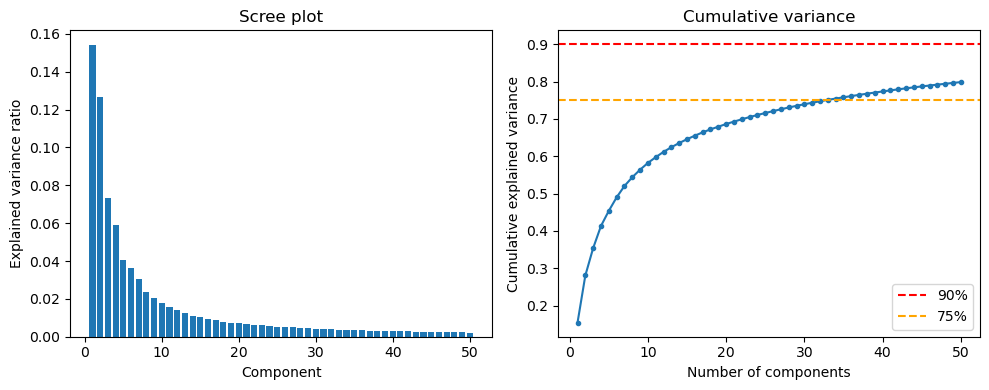

In [8]:
# PCA
X_pca, pca, scaler = clst.run_pca(X, n_components=50)
clst.plot_pca_variance(pca)

K-means cluster sizes: [np.int64(139), np.int64(162), np.int64(158), np.int64(105)]
Hierarchical cluster sizes: [np.int64(91), np.int64(193), np.int64(127), np.int64(153)]


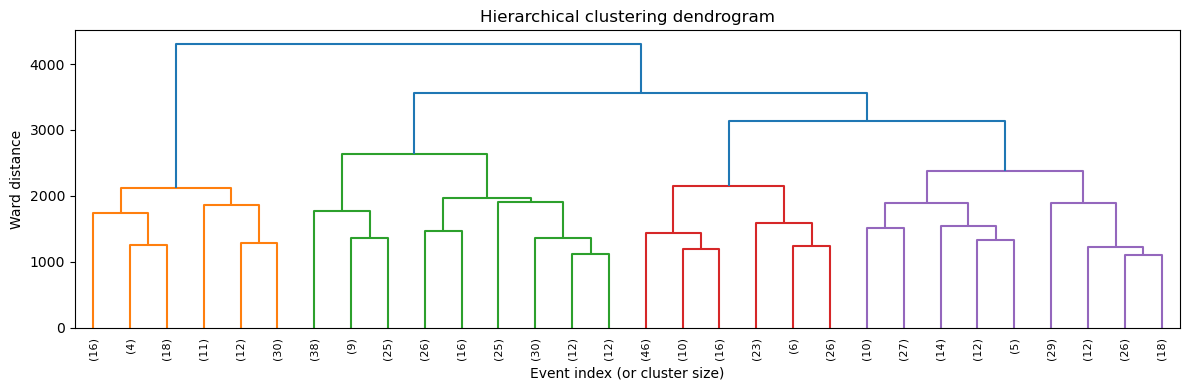

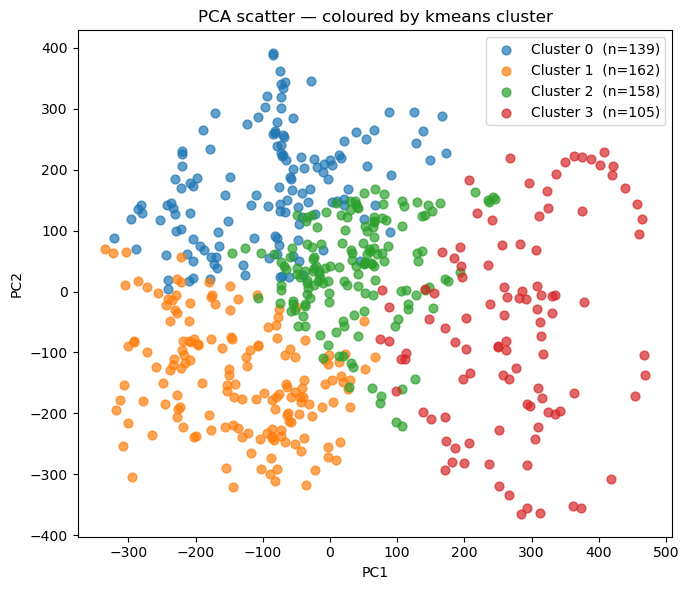

In [13]:
# clustering
labels, Z = clst.run_clustering(X_pca, n_clusters=4, method='both')
clst.plot_dendrogram(Z, n_events=X.shape[0])
clst.plot_pca_scatter(X_pca, labels, label_key='kmeans')

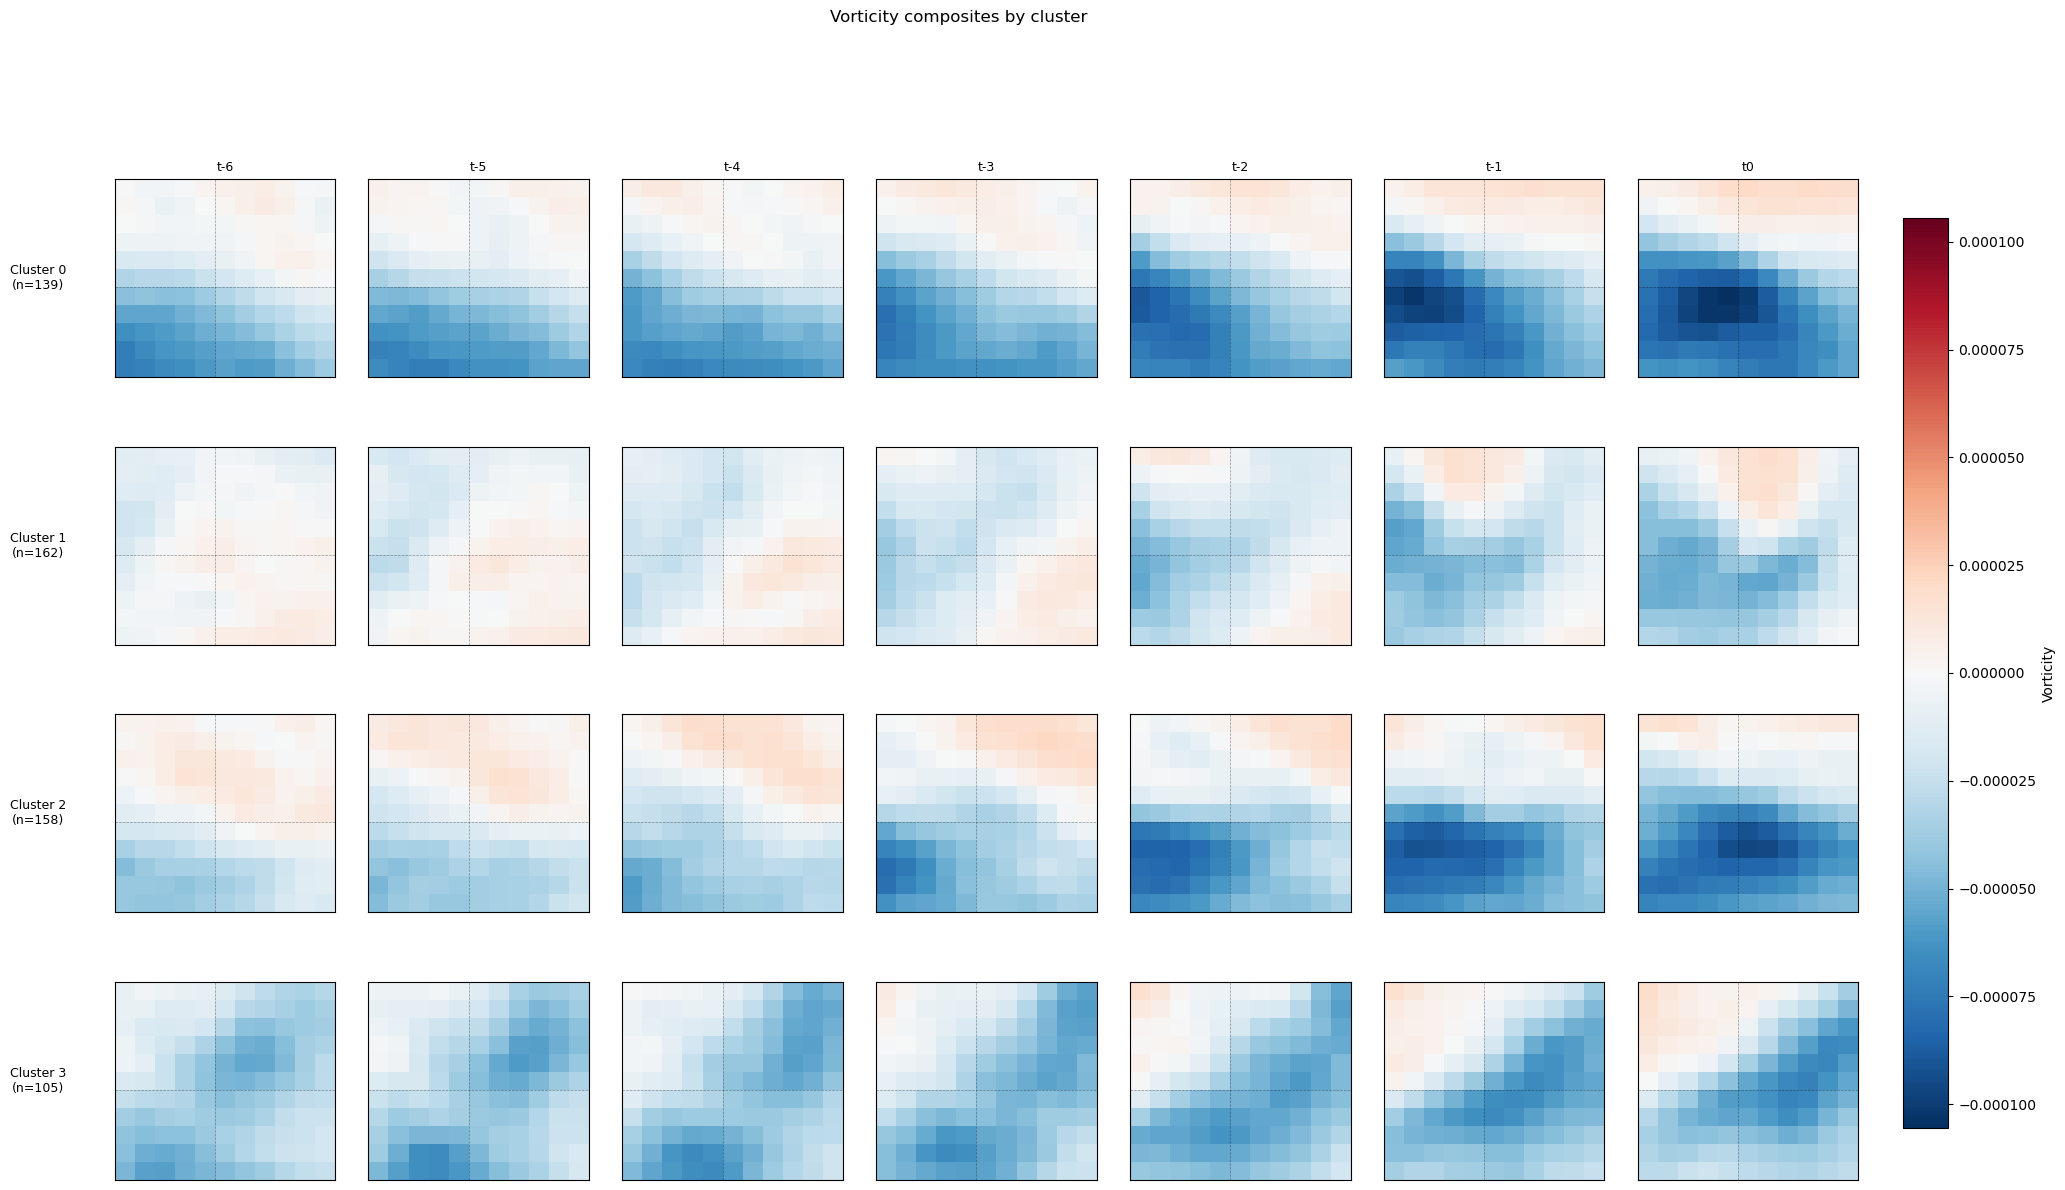

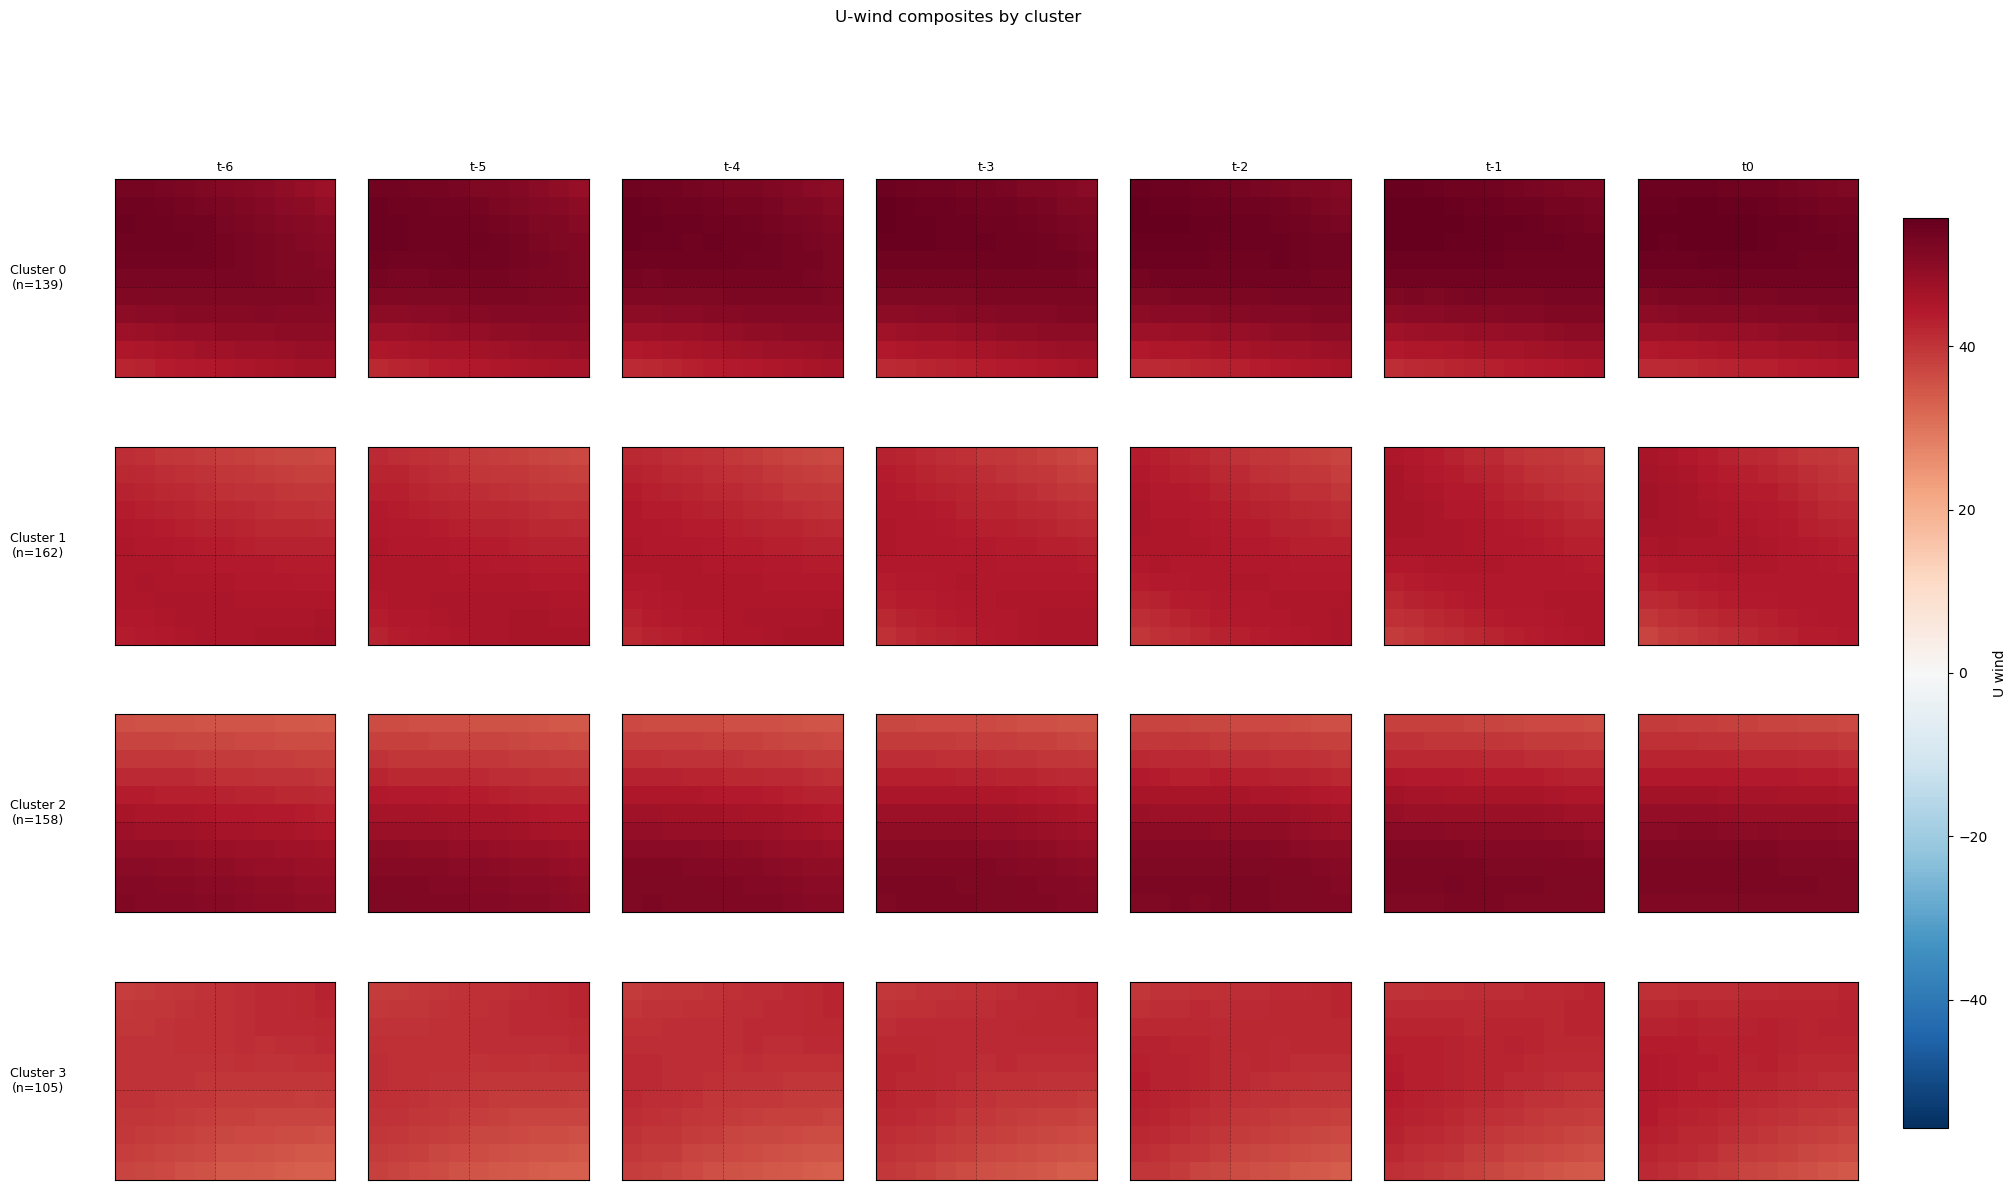

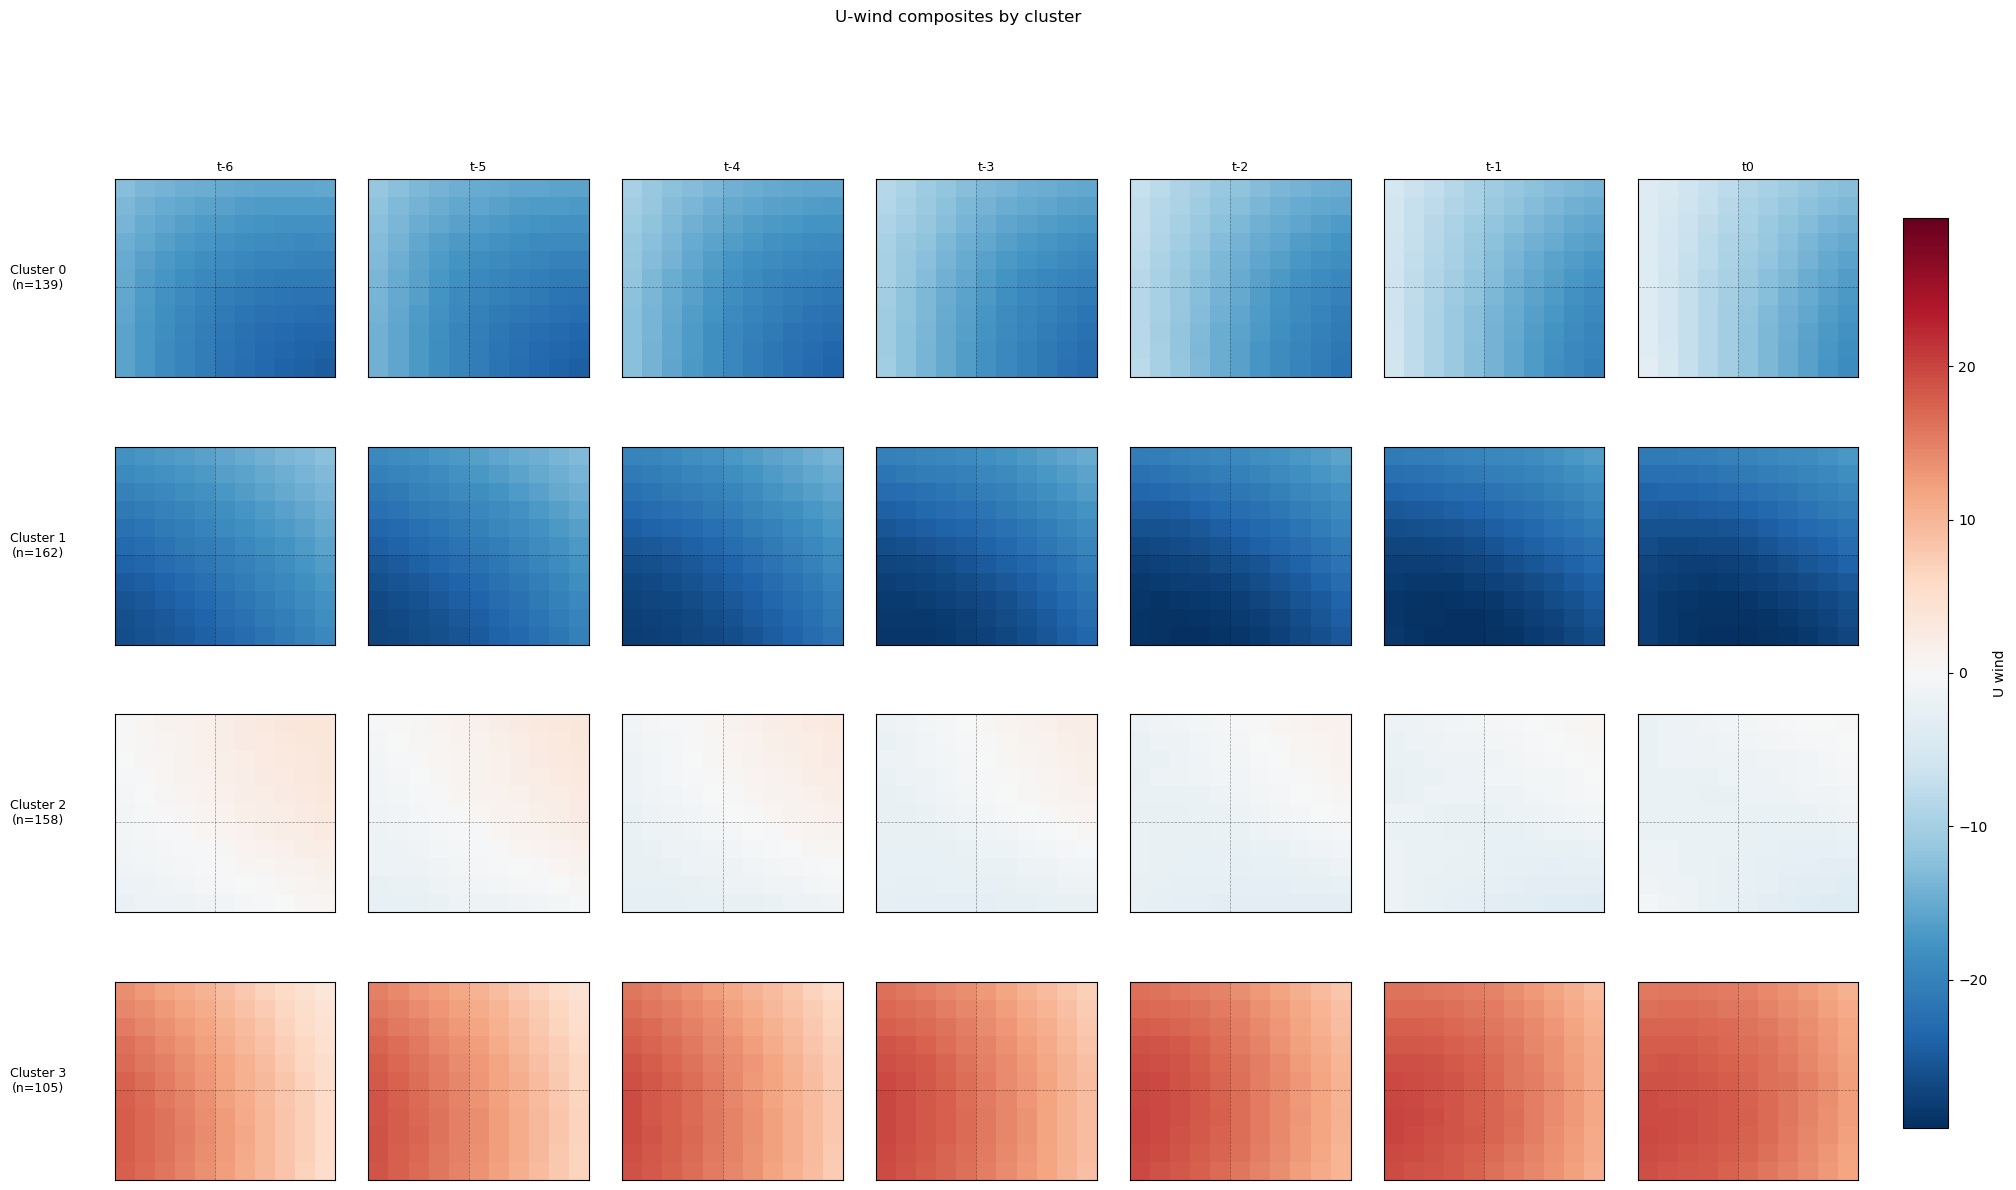

In [21]:
importlib.reload(clst)
# vorticity at ~7km
z_idx_vort = np.argmin(np.abs(zlev - 6_000.0))   # finds nearest level to 7km

fig, axes, comp_vort = clst.plot_cluster_composites(
    field_4D      = El[3].zeta_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'Vorticity',
    zlev          = zlev,
    z_idx         = z_idx_vort,
    suptitle      = 'Vorticity composites by cluster',
)

# u-wind at ~17km
z_idx_u = np.argmin(np.abs(zlev - 18_000.0))

fig, axes, comp_u = clst.plot_cluster_composites(
    field_4D      = El[3].u_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'U wind',
    zlev          = zlev,
    z_idx         = z_idx_u,
    suptitle      = 'U-wind composites by cluster',
)

# u-wind at ~17km
z_idx_v = np.argmin(np.abs(zlev - 18_000.0))

fig, axes, comp_u = clst.plot_cluster_composites(
    field_4D      = El[3].v_4D,
    cluster_labels = labels['kmeans'],
    field_name    = 'U wind',
    zlev          = zlev,
    z_idx         = z_idx_u,
    suptitle      = 'U-wind composites by cluster',
)



In [ ]:
importlib.reload(auti)
Soo=auti.event_composite_correlation(El[3].zeta_4D, composite=None, CorrKey='tyx')

In [ ]:
zbot,ztop=   np.argmin( np.abs(zlev-5_000.) ) , np.argmin( np.abs(zlev-10_000.) )
plt.plot( Soo[0][:,zbot].flatten() , '.' )
#plt.xlim(75,85)

In [ ]:
e=83
print( time[ int(El[3].time4D[e]) ] )
print( El[3].lat4D[e]  )
print( El[3].lon4D[e]  )


In [ ]:
z0=np.argmin( np.abs(zlev-zlev_event) )
z0=np.argmin( np.abs(zlev-10_000.) )
zS=np.argmin( np.abs(zlev-9_000.) )
zbot,ztop=   np.argmin( np.abs(zlev-5_000.) ) , np.argmin( np.abs(zlev-10_000.) )
zeta_zv =np.mean(El[3].zeta_4D[:,:,ztop:zbot+1,:,:],axis=2)

fig,axs=plt.subplots( 2,4 , figsize=(4*7+1,2*6) )
axs[1,3].axis('off')
dlon=lon[1]-lon[0]
dlat=A.lat[3]-A.lat[2]
print( dlat,dlon )
lonco=np.linspace( -5*dlon, 5*dlon, num=11 )
latco=np.linspace( -5*dlat, 5*dlat, num=11 )
axs=axs.flatten()
clv=1.e-4 * np.linspace(-3,3,num=51)
mlv=2.e-2*np.linspace(-2,2,num=11)
for p in np.arange(7):
    ax=axs[p] 
    t=p
    #co = ax.contour( El[3].zeta_4D[e,t,zS,:,:] , levels=clv, cmap='bwr' )
    co = ax.contourf( lonco,latco,np.mean( El[3].zeta_4D[:,t,zS,:,:],axis=0) , levels=clv, cmap='bwr' ,alpha=1.0)
    #co = ax.contourf( np.mean( zeta_zv[:,t,:,:] ,axis=0) , levels=clv, cmap='bwr' )
    li = ax.contour( lonco,latco,np.mean( El[3].upwp_4D[:,t,z0,:,:],axis=0) , levels=mlv, cmap='gray' )
    ax.set_title( f"$t_0$-{(6-p)*3} hrs ",fontsize=18)
    ax.set_xlabel( "degrees from event center" ,fontsize=18)
    ax.set_ylabel( "degrees from event center" ,fontsize=18)
#plt.colorbar(co)
#plt.colorbar( co )
    

In [ ]:
importlib.reload(auti)
hoo,xr =auti.one_dim_pdf( Soo[0][:,zbot].flatten() , nbin=30)

plt.plot(xr,hoo)
plt.xlabel('correlation')
plt.ylabel('Probablity')


In [ ]:
plt.contour( lon,lat,A.htopo )
plt.scatter( El[0].lon4D, El[0].lat4D, c=np.log10(El[0].epwp_4D[:,3,20,2,2]) , s=5 )
#plt.scatter( lon4D, lat4D, c=htopo_4D[:,3,2,2] , s=10 )


In [ ]:
print( "STOP HERE poopypants" )
print( "STOP HERE",poopypants )


In [ ]:
importlib.reload(auti)
for E in El:
    zeta_4D = E.zeta_4D
    tilt_4D = E.tilt_4D
    epwp_4D = E.epwp_4D
    upwp_4D = E.upwp_4D
    fgf_4D = E.fgf_4D
    u_4D = E.u_4D
    v_4D = E.v_4D
    precl_4D = E.precl_4D

    E['zeta_MMM'], E['zeta_super_mean'], E['zeta_super_min'], E['zeta_super_max'] = \
        auti.collapseSpaceTime(zeta_4D)

    E['epwp_MMM'], E['epwp_super_mean'], E['epwp_super_min'], E['epwp_super_max'] = \
        auti.collapseSpaceTime(epwp_4D)

    E['upwp_MMM'], E['upwp_super_mean'], E['upwp_super_min'], E['upwp_super_max'] = \
        auti.collapseSpaceTime(upwp_4D)

    E['tilt_MMM'], E['tilt_super_mean'], E['tilt_super_min'], E['tilt_super_max'] = \
        auti.collapseSpaceTime(tilt_4D)

    E['fgf_MMM'], E['fgf_super_mean'], E['fgf_super_min'], E['fgf_super_max'] = \
        auti.collapseSpaceTime(fgf_4D)

    E['u_MMM'], E['u_super_mean'], E['u_super_min'], E['u_super_max'] = \
        auti.collapseSpaceTime(u_4D)

    E['v_MMM'], E['v_super_mean'], E['v_super_min'], E['v_super_max'] = \
        auti.collapseSpaceTime(v_4D)

    E['precl_MMM'], E['precl_super_mean'], E['precl_super_min'], E['precl_super_max'] = \
        auti.collapseSpaceTime(precl_4D, TZHkey='etyx'   )


In [ ]:
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(figsize=(5, 8))
ax.plot( El[0].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[1].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[2].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[3].tilt_super_max.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

In [ ]:
from matplotlib.ticker import MaxNLocator
fig, axs = plt.subplots(1,4,figsize=(21, 8))

ax=axs[0]
ax.plot( El[0].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].u_super_mean.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[1]
ax.plot( El[0].zeta_super_min.mean(axis=0) , A.zlev )
ax.plot( El[1].zeta_super_min.mean(axis=0) , A.zlev )
ax.plot( El[2].zeta_super_min.mean(axis=0) , A.zlev )
ax.plot( El[3].zeta_super_min.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[2]
ax.plot( El[0].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[1].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[2].tilt_super_max.mean(axis=0) , A.zlev )
ax.plot( El[3].tilt_super_max.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[3]
ax.plot( El[0].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[1].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[2].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[3].upwp_super_min.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))



In [ ]:
A.zeta.shape
clv=1.e-5*np.linspace( -3.,3., num=61 )
plt.contourf( lat, zlev, np.mean( np.mean( A.zeta, axis=3) , axis=0) , levels=clv, cmap='bwr' )

In [ ]:


zeta_t0x0= El[0].zeta_4D[:,6,:,2,2]
zeta_MMMt0= El[0].zeta_MMM[0][:,6,:]

In [ ]:
El[0].zeta_MMM[0].shape

In [ ]:
z0=np.argmin( np.abs(zlev-zlev_event) )
#z0=np.argmin( np.abs(zlev-20_000.) )
zS=np.argmin( np.abs(zlev-7_000.) )

fig,axs=plt.subplots( 2,4 , figsize=(4*5+1,2*5) )
axs=axs.flatten()
e=100
clv=1.e-4 * np.linspace(-3,3,num=51)
for p in np.arange(7):
    ax=axs[p] 
    t=p
    #co = ax.contourf( El[3].zeta_4D[e,t,zS,:,:] , levels=clv, cmap='bwr' )
    co = ax.contourf( np.mean( El[3].zeta_4D[:,t,zS,:,:],axis=0) , levels=clv, cmap='bwr' )

#plt.colorbar( co )
    

In [ ]:
from matplotlib.ticker import MaxNLocator
fig, axs = plt.subplots(1,4,figsize=(21, 8))

ax=axs[0]
ax.plot( El[0].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].u_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].u_super_mean.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[1]
ax.plot( El[0].zeta_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].zeta_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].zeta_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].zeta_super_mean.mean(axis=0) , A.zlev )

ax.plot( zeta_t0x0.mean(axis=0) , A.zlev, color='black' , linestyle=':' )
ax.plot( zeta_MMMt0.mean(axis=0) , A.zlev, color='black' , linestyle='--' )

ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[2]
ax.plot( El[0].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].tilt_super_mean.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

ax=axs[3]
ax.plot( El[0].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[1].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[2].upwp_super_min.mean(axis=0) , A.zlev )
ax.plot( El[3].upwp_super_min.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))



In [ ]:
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(figsize=(5, 8))
ax.plot( El[0].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[1].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[2].tilt_super_mean.mean(axis=0) , A.zlev )
ax.plot( El[3].tilt_super_mean.mean(axis=0) , A.zlev )
ax.set_ylim( 0., 40_000.)
ax.xaxis.set_major_locator(MaxNLocator(4))

In [ ]:
z0=np.argmin( np.abs(zlev-zlev_event) )
#z0=np.argmin( np.abs(zlev-20_000.) )
zS=np.argmin( np.abs(zlev-7_000.) )
#plt.plot( tilt_super_max[:,zS])
#plt.scatter( np.log10(tilt_super_max[:,zS] ), epwp_super_max[:,z0] )
plt.scatter( np.log10(El[0].tilt_super_max[:,zS] ), El[0].epwp_super_max[:,z0] )
plt.scatter( np.log10(El[3].tilt_super_max[:,zS] ), El[3].epwp_super_max[:,z0] )


In [ ]:
z0=np.argmin( np.abs(zlev-zlev_event) )
z0=np.argmin( np.abs(zlev-20_000.) )
zS=np.argmin( np.abs(zlev-5_000.) )
#plt.plot( tilt_super_max[:,zS])
#plt.scatter( np.log10(tilt_super_max[:,zS] ), epwp_super_max[:,z0] )
#plt.scatter( (El[3].upwp_super_min[:,zS] ), El[3].upwp_super_min[:,z0] )
#plt.scatter( (El[3].precl_super_max ), El[3].upwp_super_min[:,zS] )
plt.scatter( (El[3].epwp_super_max[:,z0] ), El[3].upwp_super_min[:,zS] )
#plt.scatter( (El[2].epwp_super_mean[:,zS] ), El[2].epwp_super_max[:,z0] )


In [ ]:
importlib.reload(auti)
xdata,ydata = np.log10(tilt_super_max[:,zS]) , epwp_super_max[:,z0]
#xdata,ydata = np.sqrt(tilt_super_max[:,zS]) , epwp_super_max[:,z0]
pdf2d,xcens,ycens = auti.two_dim_pdf(xdata,ydata,nxbin=50,nybin=50,logx=False,logy=False, density=True )


In [ ]:
plt.contourf( xcens,ycens, np.log10(pdf2d+.0000001).T )
plt.colorbar()

In [ ]:
if A.ncdata !='none' and process_ncdata==True :
    caseB = Path(A.ncdata).parents[2].name
    print( f"Getting 'Mother' run {caseB} " )
    B = futi.read_case( case=caseB, nsteps=nsteps ) # , nsteps = 31*8 )
    have_caseB = True
else:
    have_caseB = False
 


if have_caseB == True:
    epwp_4D_B, time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=ds, aa=B.rho_epwp , lon=lon, lat=lat, window=window , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range )
    epwp_MMM_B = auti.collapseSpace( epwp_4D_B )
    epwp_B_super_mean = epwp_MMM_B[0].mean( axis=1 )
    epwp_B_super_min = epwp_MMM_B[1].min( axis=1 )
    epwp_B_super_max = epwp_MMM_B[2].max( axis=1 )


In [ ]:
from matplotlib.ticker import MaxNLocator

n=50 #100
n=50 #20

#print( f"time = {time_ev[n]}, lat = {lat[int(iy_ev[n])]}, lon = {lon[int(ix_ev[n])]} " )
#epwp,vort,U,zl = epwp_4D[n,5,:,5,5],zeta_4D[n,4,:,4,6], u_4D[n,4,:,4,6], zlev
epwp,vort,U,zl , V = epwp_4D[n,3,:,2,2],zeta_4D[n,3,:,2,2], u_4D[n,3,:,2,2], A.zlev , v_4D[n,3,:,2,2]
fig, ax1 = plt.subplots(figsize=(5, 8))

# First variable: upwp
ax1.plot(epwp, zl, color='tab:blue', linewidth=2)
ax1.plot(epwp_super_max[n,:], zl, color='tab:blue', linewidth=1)

if have_caseB == True:
    ax1.plot(epwp_B_super_max[n,:], zl, color='tab:blue', linewidth=1,linestyle=':')

ax1.set_xlabel("upwp", color='tab:blue')
ax1.tick_params(axis='x', colors='tab:blue')
ax1.set_ylabel("z")
ax1.set_ylim(0,40_000.)

# Second variable: U
ax2 = ax1.twiny()
ax2.plot(U, zl, color='tab:orange', linewidth=2, linestyle='--')
ax2.set_xlabel("U", color='tab:orange')
ax2.tick_params(axis='x', colors='tab:orange')

# Third variable: vorticity
ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
ax3.plot(vort, zl, color='tab:green', linewidth=2, linestyle=':')
alpha=.8
ax3.plot(  zeta_super_mean[n,:]  , zl, color='tab:green', linewidth=2, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_min[n,:]  , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_max[n,:]  , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)

ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')
ax3.set_xlim(-0.0005,0.0002 )
ax3.xaxis.set_major_locator(MaxNLocator(4))
# Optional: if pressure or model level increases downward
# ax1.invert_yaxis()


# fourth variable: V
ax4 = ax1.twiny()
ax4.spines["top"].set_position(("axes", 1.22))   # move this x-axis upward
ax4.plot(V, zl, color='tab:red', linewidth=2, linestyle=':')
ax4.set_xlabel("V", color='tab:red')
ax4.tick_params(axis='x', colors='tab:red')

# Third variable: vorticity
ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
ax3.plot(vort, zl, color='tab:green', linewidth=2, linestyle=':')
alpha=.8
ax3.plot(  zeta_super_mean[n,:]  , zl, color='tab:green', linewidth=2, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_min[n,:]  , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_max[n,:]  , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)

ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')
ax3.set_xlim(-0.0005,0.0002 )
ax3.xaxis.set_major_locator(MaxNLocator(4))
# Optional: if pressure or model level increases downward
# ax1.invert_yaxis()


plt.tight_layout()


In [ ]:
zeta_super_max.shape

In [ ]:
tilt_super_mean_mean = tilt_super_mean.mean( axis=0 )
tilt_super_min_min = tilt_super_min.min( axis=0 )
tilt_super_min_mean = tilt_super_min.mean( axis=0 )
tilt_super_min_std = tilt_super_min.std( axis=0 )
tilt_super_max_max = tilt_super_max.max( axis=0 )
tilt_super_max_mean = tilt_super_max.mean( axis=0 )
tilt_super_max_std = tilt_super_max.std( axis=0 )

zeta_super_mean_mean = zeta_super_mean.mean( axis=0 )
zeta_super_mean_std = zeta_super_mean.std( axis=0 )

zeta_super_min_min = zeta_super_min.min( axis=0 )
zeta_super_min_mean = zeta_super_min.mean( axis=0 )
zeta_super_min_std = zeta_super_min.std( axis=0 )
zeta_super_max_max = zeta_super_max.max( axis=0 )
zeta_super_max_mean = zeta_super_max.mean( axis=0 )
zeta_super_max_std = zeta_super_max.std( axis=0 )


In [ ]:
fig, ax3 = plt.subplots(figsize=(5, 8))
zl=A.zlev
## Third variable: vorticity
#ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
#ax3.plot(zeta_4D, zl, color='tab:green', linewidth=2, linestyle=':')
alpha=.8
ax3.plot(  zeta_super_mean_mean  , zl, color='tab:green', linewidth=2, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_min_mean , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)
ax3.plot(  zeta_super_min_mean - 1*zeta_super_min_std  , zl, color='tab:green', linewidth=1, linestyle=":", alpha=alpha)
ax3.plot(  zeta_super_min_mean + 1*zeta_super_min_std  , zl, color='tab:green', linewidth=1, linestyle=":", alpha=alpha)
ax3.plot(  zeta_super_max_mean , zl, color='tab:green', linewidth=1, linestyle='-', alpha=alpha)
ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')
ax3.set_xlim(-0.0003,0.0002 )

ax4 = ax3.twiny()
ax4.spines["top"].set_position(("axes", 1.22))   # move this x-axis upward

ax4.plot(  tilt_super_mean_mean  , zl, color='tab:red', linewidth=2, linestyle='-', alpha=alpha)
ax4.plot(  tilt_super_min_mean , zl, color='tab:red', linewidth=1, linestyle='-', alpha=alpha)
ax4.plot(  tilt_super_min_mean - 1*zeta_super_min_std  , zl, color='tab:red', linewidth=1, linestyle=":", alpha=alpha)
ax4.plot(  tilt_super_min_mean + 1*zeta_super_min_std  , zl, color='tab:red', linewidth=1, linestyle=":", alpha=alpha)
ax4.plot(  tilt_super_max_mean , zl, color='tab:red', linewidth=1, linestyle='-', alpha=alpha)


ax4.set_xlabel("Tilting Mag", color='tab:red')
ax4.tick_params(axis='x', colors='tab:red')




In [ ]:
nt,nz,ny,nx = np.shape( A.rho_epwp )
masktopo=A.htopo <  0.01
masktopo3D = np.tile(masktopo[None, :, :], ( nz, 1, 1))

In [ ]:
flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]


flev=0.1*np.asarray( flev )
print(flev)
flev2 = np.concatenate( [ -np.flip(flev) , flev ] )


cmapN='gist_ncar'

cmap = plt.cm.bwr  #gist_ncar  # Or any other colormap
cmap = plt.cm.gist_ncar # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)
norm2 = mcolors.BoundaryNorm(boundaries=flev2, ncolors=cmap.N, clip=False)

fig,axs = plt.subplots( 1, 2, figsize=(16,8) )


p=0
ax=axs[p]
ax.contourf( A.lat,A.zlev, np.mean( np.mean(A.rho_epwp[:,:,:,:], axis=0 ), axis=2 ) , levels=flev, cmap=cmap , norm=norm, extend='both' )
#plt.contourf( A.lat,A.zlev, np.mean( np.mean(A.rho_upwp, axis=0 ), axis=2 ) , levels=flev2, cmap=cmap , norm=norm2, extend='both' )
ax.set_ylim( 0. , 40_000. )

p=1
ax=axs[p]
ax.contourf( A.lat,A.zlev, np.mean( np.mean(B.rho_epwp[:,:,:,:], axis=0 )*masktopo3D , axis=2 ) / (np.mean( masktopo3D, axis=2) + 0.1) , levels=flev, cmap=cmap , norm=norm, extend='both' )
ax.contour( A.lat,A.zlev, np.mean( np.mean(B.u[:,:,:,:], axis=0 )*masktopo3D , axis=2 ) / (np.mean( masktopo3D, axis=2) + 0.1) , levels=21, colors='black')
ax.contour( A.lat,A.zlev, np.mean( np.mean(B.zeta[:,:,:,:], axis=0 )*masktopo3D , axis=2 ) / (np.mean( masktopo3D, axis=2) + 0.1) , levels=11, colors='gray')

#plt.contourf( A.lat,A.zlev, np.mean( np.mean(A.rho_upwp, axis=0 ), axis=2 ) , levels=flev2, cmap=cmap , norm=norm2, extend='both' )
ax.set_ylim( 0. , 40_000. )




In [ ]:
print( np.concatenate( [ -np.flip(flev) , flev ] ) )